In [1]:
# Load dataset
import pandas as pd


df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
X = df.drop(['id', 'stroke'], axis=1)
y = df['stroke']


# for col in X.columns:
#     print(col, df[col].unique(), "\n")

print(f"class = 0 : {round(((y==0).sum()/(y.index[-1]+1))*100,2)}%")
print(f"class = 1 : {round(((y==1).sum()/(y.index[-1]+1))*100,2)}%")

class = 0 : 95.13%
class = 1 : 4.87%


In [2]:
# Splits data into 80/20 ratio
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
# Preprocess & Model's Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier


cate_cols = [col for col in X.select_dtypes(include='str').columns]

preprocess = ColumnTransformer(
    transformers = [
        ('encode_cols', OneHotEncoder(handle_unknown='ignore'), cate_cols)
    ],
    remainder='passthrough'
)

sp_weight = round((y==0).sum() / (y==1).sum(), 2)

pipeline = Pipeline([
    ('preprocessor', preprocess),
    ('model', XGBClassifier(objective='binary:logistic', eval_metric='logloss', scale_pos_weight=sp_weight, random_state=42))
])

In [4]:
# tune hyperparameters
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__gamma": [0, 1],
    "model__reg_alpha": [0, 0.5],
    "model__reg_lambda": [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_cv = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring='recall',
    n_jobs=-1,
    cv=cv,
    verbose=1
)

In [5]:
# train model
rs_cv.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.8, 1.0], 'model__gamma': [0, 1], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the

In [6]:
predictions = rs_cv.predict(X_test)
print(predictions)

[1 0 0 ... 0 0 0]


In [7]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, recall_score


print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

train_recall = rs_cv.predict(X_train)
print(f"\n\nTraining Recall : {round(recall_score(y_train, train_recall)*100, 2)}")
print(f"Testing Recall : {round(recall_score(y_test, predictions)*100, 2)}")

              precision    recall  f1-score   support

           0       0.99      0.67      0.80       972
           1       0.12      0.84      0.20        50

    accuracy                           0.68      1022
   macro avg       0.55      0.76      0.50      1022
weighted avg       0.95      0.68      0.77      1022



Confusion Matrix
[[653 319]
 [  8  42]]


Training Recall : 92.96
Testing Recall : 84.0


Text(0.5, 1.0, 'Confusion Matrix')

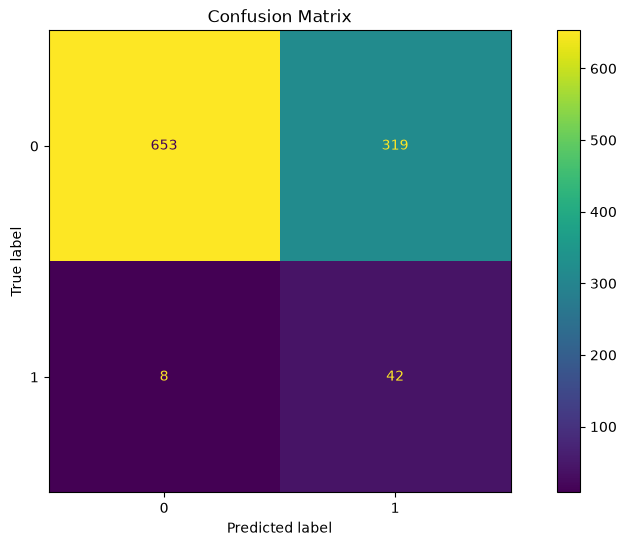

In [9]:
# Visualize Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(12, 6))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax)
ax.set_title("Confusion Matrix")